<a href="https://colab.research.google.com/github/manuelagutierrezss16/Integraci-n-de-Datos-y-Prospectiva/blob/main/Manuela_Guti%C3%A9rrez_(muestreo)_INTEGRACION_DE_DATOS_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **CASO DE ESTUDIO COMPLETO**

**Caso de Estudio** Gestión de Riesgo Operacional y de Crédito AutoRiesgo S.A.

**Objetivos del Negocio**
• AutoRiesgo S.A. es una compañía especializada en el otorgamiento de créditos vehiculares para flotas comerciales.
• La empresa busca desarrollar un modelo estadístico de gestión de riesgos operacionales y de mora para estimar el impacto financiero de los vehículos colisionados o en impago, permitiéndole proyectar reservas de capital e integrar estrategias de mitigación.

**Abstracción**
• Los eventos de riesgo con mayor impacto económico están asociados al impago de créditos combinado con el costo de recuperación o siniestralidad de los vehículos.
• Para ello, se requiere construir la Distribución Agregada de Pérdidas (LDA) combinando la Frecuencia (mora/siniestros semanales) y la Severidad (costo promedio por evento).

 **Técnicas a utilizar**
 • Análisis Exploratorio de Datos (EDA): Tablas de frecuencia, marcas de clase e histogramas.
 • Estadística Descriptiva: Cálculo de métricas de tendencia central (media) y dispersión (varianza, desviación estándar, asimetría y curtosis).

 **Variables del Modelo**
 • Frecuencia ($N$): Número de créditos en mora con siniestro por semana (eventos/semana).
  • Severidad ($S$): Costo promedio de liquidación/recuperación por cada vehículo (USD/evento).
   • Pérdida Agregada ($\text{LDA} = N \times S$): Impacto financiero semanal en USD.

# 0. Carga de librerias

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd #Leer archivos
import matplotlib.pyplot as plt #Graficar
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') # los warningss existen porque la tabla no es del mismo tamaño toda

#1. Generamos y Cargamos los datos de trabajo

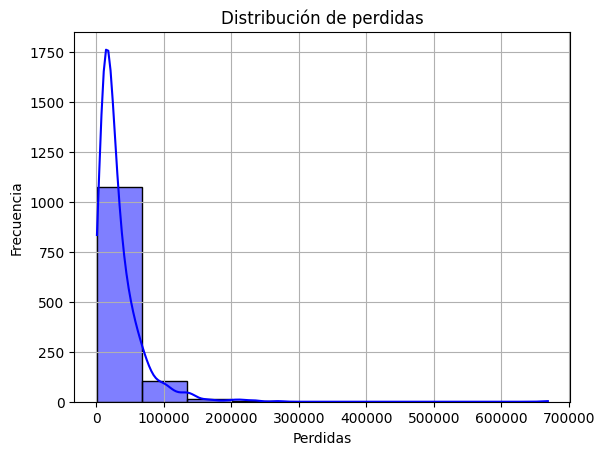

In [ ]:
np.random.seed(42)  # Semilla para reproducibilidad
n_samples = 1200    # Cumple con el requisito de más de 1000 datos

# Frecuencia (Número de eventos de riesgo por semana)
# Severidad (Costo promedio por evento en USD)
Frecuencia = np.random.poisson(lam=12, size=n_samples) + 1  # Evitar ceros
Severidad = np.random.lognormal(mean=7.5, sigma=0.8, size=n_samples)

# Creación de DataFrame principal
XDB = pd.DataFrame({
    'ID_Semana': np.arange(1, n_samples + 1),
    'Frecuencia': Frecuencia,
    'Severidad': Severidad
    })
LDA=XDB['Frecuencia']*XDB['Severidad']

# Se grafica
plt.figure()
sns.histplot(LDA,color='blue',bins=10,kde=True)
plt.title('Distribución de perdidas')
plt.xlabel('Perdidas')
plt.ylabel('Frecuencia')
plt.grid()
plt.show()

#2. Se procede con la creación de los concentradores de información.

In [ ]:
import random
random.seed(42)
XC=np.array(random.choices (LDA,k=5))
XC= np.sort(XC) #ORGANIZA DE MENOR A MAYOR
print("Los concentradores de información son:",XC)

Los concentradores de información son: [ 9178.8457035  11922.78375812 18335.54011778 39953.44907777
 69691.27208814]


#3. Se clasifican los datos de acuerdo con los concentradores de información

In [ ]:
d= np.abs(XC-LDA.iloc[0,]) #La distancia de un dato a un concentrador
nc= np.argmin(d)
print("El dato pertenece a la categoria:",nc)
# aca nos dice ell dato seleccionado en que categoria esta (a cual se parece más)

El dato pertenece a la categoria: 4


In [ ]:
box0= [];box1=[];box2= [];box3=[];box4= []
Boxes=[box0,box1,box2,box3,box4]
for k in range(len(LDA)):
    d= np.abs(XC-LDA.iloc[k,])/XC
    #Acá se divide para que de numeros mas pequeños (entre 0 y 1)
    nc= np.argmin(d) # Numero de la caja en donde voy a meter el dato

    XC[nc,]=(XC[nc,]+LDA.iloc[k,])/2  #Actualizamos el centroide de la caja

    Boxes[nc].append(LDA.iloc[k,])
    Boxes[0]  #CLICK DERECHO EJECUTAR SELECCION
    Boxes[4] # perdidads catastroficas

In [ ]:
# CUANTOS DATOS HAY EN CADA CAJA
print(len(Boxes[0]),len(Boxes[1]),len(Boxes[2]),len(Boxes[3]),len(Boxes[4]))
# DETERMINAR EL PORCENTAJE DE DATOS POR CAJA


pm=[] #Vector dde porcentajes
for j in range (5):
  pd=len(Boxes[j])/len(LDA)
  pm.append(pd)
print("El porcentaje de los datos es:",pm)
pm= (np.array(pm)*1000).astype(int)
print ("EL porcentaje de datos que se usan es:",pm) # cuantos datos saco de cada caja si necesito mil datos

208 156 296 325 215
El porcentaje de los datos es: [0.17333333333333334, 0.13, 0.24666666666666667, 0.2708333333333333, 0.17916666666666667]
EL porcentaje de datos que se usan es: [173 130 246 270 179]


#4. Sacamos datos por caja y creamos una LDA 2

(998,)
La media de los datos observados es: 33255.77991867194
La media de los datos externos es: 32922.35132334329
El error relativo porcentual es: 1.002618480589127


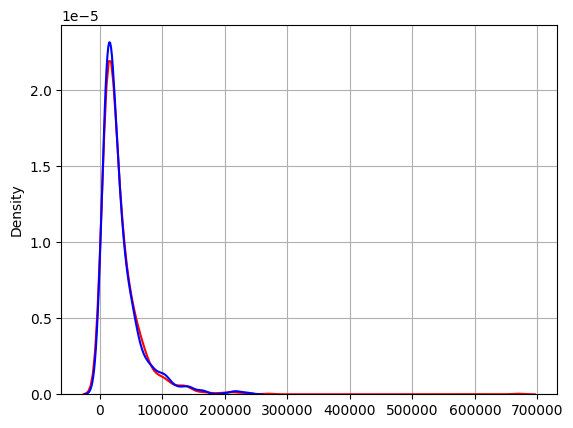

In [ ]:
LDA2=[] #Aqui van a quedar los 1000 datos
# random.choices(Boxes[0],k=379)

for j in range(5):
  LDA2. extend(random.choices(Boxes[j],k=pm[j]))
LDA2=np.array (LDA2)

print(LDA2.shape)

# se comprueban las metricas estadisticas
uo=np.mean(LDA) #datos observados son los originales
print("La media de los datos observados es:",uo)
ue=np.mean(LDA2) #datos externos, los que seleccionamos
print("La media de los datos externos es:",ue)

du=(uo-ue)/uo
print("El error relativo porcentual es:",du*100)

plt.figure()
sns.kdeplot(LDA, color='red', label='Datos Observados')
sns.kdeplot(LDA2, color='blue', label='Datos Externos')
plt.grid()
plt.show()

#FALTA LA VARIANZA DESVIACION ESTANDAR CURTOSIS...

#5. Medidas de tendecia central



In [ ]:
import scipy.stats

# 1. Media: Valor esperado de una pérdida (¿Qué es lo más común que pase?)
uo = np.mean(LDA) # Media de los datos observados (originales)
ue = np.mean(LDA2) # Media de los datos externos (seleccionados)
print(f"\nMedia de LDA (observados): {uo:.2f}")
print(f"Media de LDA2 (externos): {ue:.2f}")

# 2. Varianza: Indica qué tan dispersos están los datos alrededor de la Media.
# Una varianza alta significa que los datos están muy extendidos, mientras que una baja indica que están más agrupados.
var_o = np.var(LDA)
var_e = np.var(LDA2)
print(f"\nVarianza de LDA (observados): {var_o:.2f}")
print(f"Varianza de LDA2 (externos): {var_e:.2f}")

# 3. Desviación estándar: Es la raíz cuadrada de la varianza.
# Representa la cantidad promedio de dispersión de los valores de los datos con respecto a la media.
sigma_o = np.std(LDA)
sigma_e = np.std(LDA2)
print(f"\nDesviación estándar de LDA (observados): {sigma_o:.2f}")
print(f"Desviación estándar de LDA2 (externos): {sigma_e:.2f}")

# 4. Intervalo de variación (o Intervalo de Confianza aproximado al 95%):
# Este intervalo, comúnmente calculado como la media ± 2 veces la desviación estándar,
# nos da un rango donde se espera que se encuentre la mayoría de los datos (aproximadamente el 95% para una distribución normal).
print(f"\nIntervalo de variación de LDA (observados): [{uo - 2 * sigma_o:.2f}, {uo + 2 * sigma_o:.2f}]")
print(f"Intervalo de variación de LDA2 (externos): [{ue - 2 * sigma_e:.2f}, {ue + 2 * sigma_e:.2f}]")

# 5. Coeficiente de asimetría (Skewness): Mide la asimetría de la distribución de los datos.
# Un valor de 0 indica simetría perfecta. Valores positivos indican una cola más larga a la derecha,
# mientras que valores negativos indican una cola más larga a la izquierda.
cas_o = LDA.skew() # Already correct for Series
cas_e = scipy.stats.skew(LDA2) # Use scipy for ndarray
print(f"\nCoeficiente de asimetría de LDA (observados): {cas_o:.2f}")
print(f"Coeficiente de asimetría de LDA2 (externos): {cas_e:.2f}")

# 6. Coeficiente de curtosis: Mide la 'puntiagudez' o 'aplanamiento' de la distribución de los datos en comparación con una distribución normal.
# Un valor de 0 (exceso de curtosis) indica una forma similar a la distribución normal (mesocúrtica).
# Valores positivos indican colas más pesadas y un pico más alto (leptocúrtica),
# mientras que valores negativos indican colas más ligeras y un pico más plano (platocúrtica).
cur_o = LDA.kurt() # Already correct for Series
cur_e = scipy.stats.kurtosis(LDA2) # Use scipy for ndarray
print(f"\nCoeficiente de curtosis de LDA (observados): {cur_o:.2f}")
print(f"Coeficiente de curtosis de LDA2 (externos): {cur_e:.2f}")


Media de LDA (observados): 33255.78
Media de LDA2 (externos): 32922.35

Varianza de LDA (observados): 1350734747.08
Varianza de LDA2 (externos): 1054783356.15

Desviación estándar de LDA (observados): 36752.34
Desviación estándar de LDA2 (externos): 32477.43

Intervalo de variación de LDA (observados): [-40248.91, 106760.47]
Intervalo de variación de LDA2 (externos): [-32032.51, 97877.21]

Coeficiente de asimetría de LDA (observados): 6.04
Coeficiente de asimetría de LDA2 (externos): 2.59

Coeficiente de curtosis de LDA (observados): 79.37
Coeficiente de curtosis de LDA2 (externos): 8.96


Datos pasados

In [ ]:
import pandas as pd
NI = 10  # Número de Intervalos
counts, Limits = np.histogram(LDA, bins=NI)

LI = Limits[:-1]            # Límites inferiores
LS = Limits[1:]             # Límites superiores
fi = counts / sum(counts)   # Frecuencia relativa (porcentaje)
MC = (LI + LS) / 2          # Marca de clase

# DataFrame resumen del histograma
df_hist = pd.DataFrame(np.column_stack((LI, LS, counts, fi, MC)))
df_hist.columns = ["LI", "LS", "ND", "fi", "MC"]
print("--- TABLA DE FRECUENCIAS DE LA LDA ---")
display(df_hist)

--- TABLA DE FRECUENCIAS DE LA LDA ---


,LI,LS,ND,fi,MC
0,1156.324099,67943.337521,1076.0,0.896667,34549.830810
1,67943.337521,134730.350943,102.0,0.085000,101336.844232
2,134730.350943,201517.364366,15.0,0.012500,168123.857655
3,201517.364366,268304.377788,5.0,0.004167,234910.871077
4,268304.377788,335091.391210,1.0,0.000833,301697.884499
5,335091.391210,401878.404632,0.0,0.000000,368484.897921
6,401878.404632,468665.418055,0.0,0.000000,435271.911344
7,468665.418055,535452.431477,0.0,0.000000,502058.924766
8,535452.431477,602239.444899,0.0,0.000000,568845.938188
9,602239.444899,669026.458321,1.0,0.000833,635632.951610


In [ ]:
#1 Media: Valor esperado de una pérdida (¿Qué es lo más común que pase?)
u= np.sum(MC*fi)
print("La media es: ",u)

#2 Varianza: Indica que tan dispersos están los datos al reddedor de la Media
varc=np.sum(((MC-u)**2)*fi)
print("la varianza es:", varc)

#3 La desviación: raiz cuadrada de la varianza
sigma=np.sqrt(varc)
print("la desviación es: ", sigma)

#4 Intervalo de variación de las perdidas
print("El límite inferior es:", u-2*sigma) # se multiplica *2 por el intervalo de confianza, en 2 sigmas se encuentra el 95% de los datos,
print("El liite superior es:", u+2*sigma)#  si solo fuera 1 se encuentra el 68% de los datos

#5 coeficiente de asimetria
cas=np.sum(((MC-u)**3)*fi)/((sigma**3))
print("El coeficiente de asimetría es:", cas)

#6 Coeficiente de curtosis
cur = np.sum(((MC - u)**4) * fi) / (sigma**4) - 3
print("El coeficiente de curtosis es:", cur)


La media es:  43454.76593302578
la varianza es: 1050696771.461432
la desviación es:  32414.45312605832
El límite inferior es: -21374.14031909086
El liite superior es: 108283.67218514242
El coeficiente de asimetría es: 7.537660946684311
El coeficiente de curtosis es: 101.85982556069776


#4. Analisis de resultados

De acuerdo con el motodo de integración de datos por muestreo aleatorio y concentradores de información, la discrepancia que se obtuvo para la media de las distribuciones (DATOS OBSERBADOS:LDA, DATOS EXTERNOS:LDA2) estuvo por debajo del 1% en promedio, lo que indica que el 99% de los datos aproximadamente fueron correctamente seleccionados.
Este proceso de muestreo se hizo con el fin de lograr una confiabilidad del 99,9% en la estimacion de las perdidas por créditos vehiculares en mora combinados con siniestros.

Es importante mencionar que las medias de los datos observados y los externos fueron:

Media de LDA (observados): 33255.78
Media de LDA2 (externos): 32922.35

* El promedio es prácticamente el mismo. La pérdida promedio de los datos observados y la de los datos externos son muy parecidas, están alrededor de treinta y tres mil dólares en ambos casos, con una diferencia mínima entre ellas. Esto nos dice que la muestra externa, aunque es más pequeña, logró capturar bien cuál es la pérdida típica o esperada que tiene la empresa cada semana.

Varianza de LDA (observados): 1350734747.08
Varianza de LDA2 (externos): 1054783356.15

Desviación estándar de LDA (observados): 36752.34
Desviación estándar de LDA2 (externos): 32477.43

Intervalo de variación de LDA (observados): [-40248.91, 106760.47]
Intervalo de variación de LDA2 (externos): [-32032.51, 97877.21]

* En ambos casos, cuando se calcula el rango usando el promedio y la desviación, el límite de abajo termina siendo un número negativo, lo cual no tiene sentido porque una pérdida no puede ser negativa. Que este mismo problema aparezca tanto en los datos completos como en la muestra reducida confirma que no es un error puntual de una sola muestra, sino que refleja que ninguno de los dos conjuntos de datos se comporta como una distribución normal o simétrica, BASICAMENTE ESTA GANANDO DINERO EN VEZ DE PERDERLO, pero eso no puede pasar en este caso, porque estamos hablando de pérdidas por mora o por choques de carros, y una pérdida nunca puede ser un número negativo, como mínimo puede ser cero.

Coeficiente de asimetría de LDA (observados): 6.04
Coeficiente de asimetría de LDA2 (externos): 2.59

Coeficiente de curtosis de LDA (observados): 79.37
Coeficiente de curtosis de LDA2 (externos): 8.96

* Los dos conjuntos apuntan en la misma dirección respecto a la forma de la distribución. Tanto en los datos observados como en los externos, el coeficiente de asimetría es un número positivo y bastante alto, y el coeficiente de curtosis también es un número positivo muy alto. Esto significa que ambos conjuntos de datos, sin excepción, muestran el mismo patrón de comportamiento: la mayoría de las semanas tienen pérdidas relativamente bajas y parecidas entre ellas, pero existen algunas semanas puntuales donde la pérdida se dispara muchísimo por encima de lo normal.

